In [3]:
import torch

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!rm -rf /content/EuroSAT

In [6]:
!cp -r /content/drive/MyDrive/EuroSAT /content/EuroSAT

In [7]:
import os
import pandas as pd
root="/content/EuroSAT"
pd.read_csv('/content/EuroSAT/train.csv').head()

,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [8]:
import json
train_df=pd.read_csv('/content/EuroSAT/train.csv')
val_df=pd.read_csv('/content/EuroSAT/validation.csv')
test_df=pd.read_csv('/content/EuroSAT/test.csv')
print(train_df.head())
print(train_df.shape, val_df.shape, test_df.shape)
with open('/content/EuroSAT/label_map.json') as f:
  label_map=json.load(f)
print(label_map)


   Unnamed: 0                                           Filename  Label  \
0       16257                      AnnualCrop/AnnualCrop_142.jpg      0   
1        3297  HerbaceousVegetation/HerbaceousVegetation_2835...      2   
2       17881               PermanentCrop/PermanentCrop_1073.jpg      6   
3        2223                      Industrial/Industrial_453.jpg      4   
4        4887  HerbaceousVegetation/HerbaceousVegetation_1810...      2   

              ClassName  
0            AnnualCrop  
1  HerbaceousVegetation  
2         PermanentCrop  
3            Industrial  
4  HerbaceousVegetation  
(18900, 4) (5400, 4) (2700, 4)
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


<PIL.Image.Image image mode=RGB size=64x64 at 0x7F26B678DE20> (64, 64)


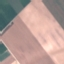

In [9]:
from PIL import Image
from torch.utils.data import Dataset

class EuroSATCSVDataset(Dataset):
  def __init__(self,csv_path,root_dir,transform=None):
    self.df=pd.read_csv(csv_path)
    self.root_dir=root_dir
    self.transform=transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    row=self.df.iloc[idx]
    img_path=os.path.join(self.root_dir,row['Filename'])
    image=Image.open(img_path).convert('RGB')
    label=int(row['Label'])
    if self.transform:
      image=self.transform(image)
    return image,label
root='/content/EuroSAT'
test_dataset=EuroSATCSVDataset(os.path.join(root,'train.csv'),root)
img,label=test_dataset[0]
print(img,img.size)
img

In [10]:
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

eval_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [11]:
train_dataset=EuroSATCSVDataset(os.path.join(root,'train.csv'),root,transform=train_transform)
val_dataset=EuroSATCSVDataset(os.path.join(root,'validation.csv'),root,transform=eval_transform)
test_dataset=EuroSATCSVDataset(os.path.join(root,'test.csv'),root,transform=eval_transform)


In [12]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [16]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

model=models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
  param.requires_grad=False

num_features=model.fc.in_features
model.fc=nn.Linear(num_features,10)

model=model.to('cpu')
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
total=sum(p.numel() for p in model.parameters())


In [86]:
import torch.optim as optim
from tqdm import tqdm
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

In [15]:
import torch.optim as optim
from tqdm import tqdm
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch 1: 100%|██████████| 591/591 [01:37<00:00,  6.05it/s]


Epoch 1/10, Loss: 0.6435, Val Accuracy: 0.8906


Epoch 2: 100%|██████████| 591/591 [01:38<00:00,  6.00it/s]


Epoch 2/10, Loss: 0.3494, Val Accuracy: 0.9102


Epoch 3: 100%|██████████| 591/591 [01:38<00:00,  6.02it/s]


...

Epoch 8/10, Loss: 0.2056, Val Accuracy: 0.9380


Epoch 9: 100%|██████████| 591/591 [01:38<00:00,  6.02it/s]


Epoch 9/10, Loss: 0.1979, Val Accuracy: 0.9359


Epoch 10: 100%|██████████| 591/591 [01:37<00:00,  6.04it/s]


Epoch 10/10, Loss: 0.1901, Val Accuracy: 0.9381


In [87]:
for param in model.parameters():
  param.requires_grad=True

optimizer=optim.Adam(model.parameters(),lr=0.0001)

In [17]:
num_epochs=10
for epoch in range(num_epochs):
  model.train()
  running_loss=0.0
  for images,labels in tqdm(train_loader,desc=f'fine-tuning epoch {epoch+1}'):
    images=images.to('cuda')
    labels=labels.to('cuda')
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for images,labels in val_loader:
      images=images.to('cuda')
      labels=labels.to('cuda')
      outputs=model(images)
      _,predicted=torch.max(outputs,1)
      total+=labels.size(0)
      correct+=(predicted==labels).sum().item()
  val_accuracy=correct/total
  torch.save(model.state_dict(),f'/content/drive/MyDrive/EuroSAT_checkpoint_epoch{epoch+1}.pt')
  print(f'Fine-tune Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')


fine-tuning epoch 1: 100%|██████████| 591/591 [03:47<00:00,  2.60it/s]


Fine-tune Epoch 1/10, Loss: 0.1355, Val Accuracy: 0.9720


fine-tuning epoch 2: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


Fine-tune Epoch 2/10, Loss: 0.0791, Val Accuracy: 0.9657


fine-tuning epoch 3: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


...

Fine-tune Epoch 8/10, Loss: 0.0254, Val Accuracy: 0.9793


fine-tuning epoch 9: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


Fine-tune Epoch 9/10, Loss: 0.0221, Val Accuracy: 0.9828


fine-tuning epoch 10: 100%|██████████| 591/591 [03:45<00:00,  2.62it/s]


Fine-tune Epoch 10/10, Loss: 0.0208, Val Accuracy: 0.9813


In [18]:
model.load_state_dict(torch.load('/content/drive/MyDrive/EuroSAT_checkpoint_epoch10.pt', map_location='cpu'))
model = model.to('cpu')
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
from sklearn.metrics import classification_report ,confusion_matrix
import numpy as np

model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
  for images,labels in tqdm(test_loader,desc='Testing'):
    images=images.to('cpu')
    outputs=model(images)
    _,predicted=torch.max(outputs,1)
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.numpy())

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
print(classification_report(all_labels, all_preds, target_names=class_names))


Testing: 100%|██████████| 85/85 [00:13<00:00,  6.13it/s]

                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.99      0.96       300
              Forest       0.99      1.00      0.99       300
HerbaceousVegetation       0.97      0.99      0.98       300
             Highway       1.00      0.98      0.99       250
          Industrial       0.99      1.00      0.99       250
             Pasture       0.99      0.95      0.97       200
       PermanentCrop       0.97      0.94      0.96       250
         Residential       1.00      1.00      1.00       300
               River       0.98      0.96      0.97       250
             SeaLake       1.00      1.00      1.00       300

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



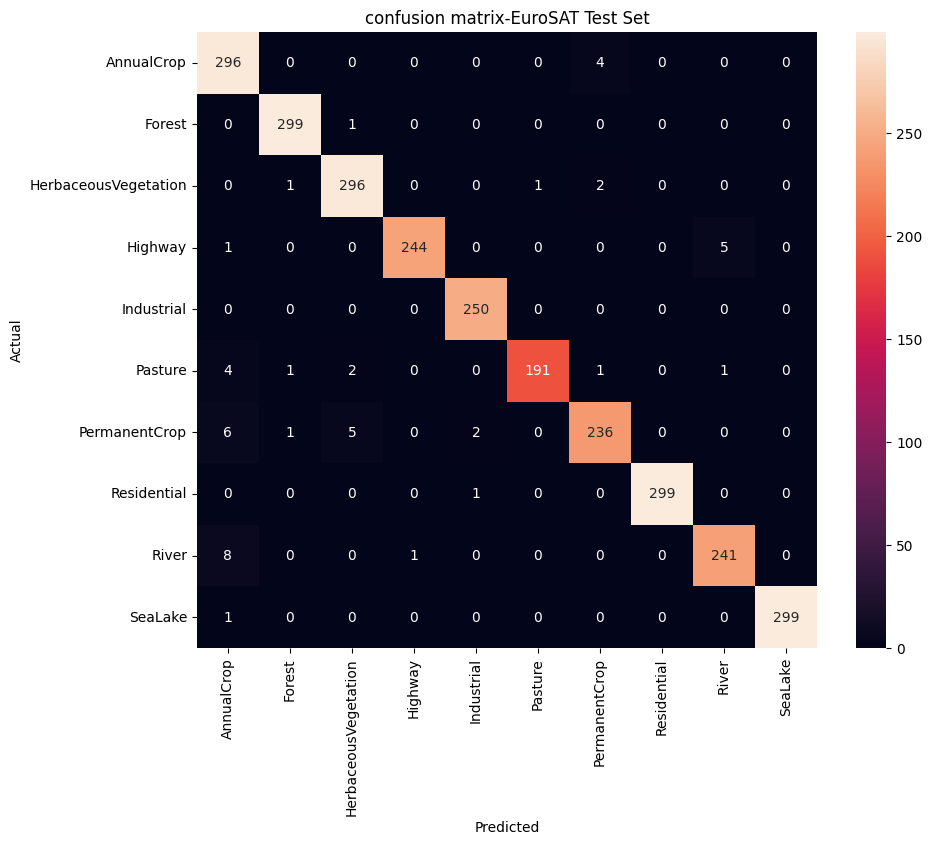

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cm=confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('confusion matrix-EuroSAT Test Set')
plt.show()

In [19]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [21]:
from huggingface_hub import HfApi,create_repo
repoid="chitransh001/euroset-resnet50"
create_repo(repoid,repo_type="model",exist_ok=True)

RepoUrl('https://huggingface.co/chitransh001/euroset-resnet50', endpoint='https://huggingface.co', repo_type='model', repo_id='chitransh001/euroset-resnet50')

In [22]:
from huggingface_hub import upload_file
upload_file(
    path_or_fileobj="/content/drive/MyDrive/EuroSAT_checkpoint_epoch10.pt",
    path_in_repo="eurosat_resnet50.pt",
    repo_id=repoid,
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...SAT_checkpoint_epoch10.pt:   1%|          |  555kB / 94.4MB            

CommitInfo(commit_url='https://huggingface.co/chitransh001/euroset-resnet50/commit/570e5c5738700323362cd0911fbe5b7089b28c2d', commit_message='Upload eurosat_resnet50.pt with huggingface_hub', commit_description='', oid='570e5c5738700323362cd0911fbe5b7089b28c2d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/chitransh001/euroset-resnet50', endpoint='https://huggingface.co', repo_type='model', repo_id='chitransh001/euroset-resnet50'), pr_revision=None, pr_num=None)

In [19]:
import ee
ee.Authenticate()
ee.Initialize(project='eurosat-resnet50')
image=ee.Image('USGS/SRTMGL1_003')
print(image.getInfo()['bands'][0]['id'])

elevation


In [59]:
import ee

ee.Initialize(project='eurosat-resnet50')
point = ee.Geometry.Point([77.554275, 28.570071])
roi = point.buffer(5000).bounds()

def get_composite(start_date, end_date, region):
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(region)
                  .filterDate(start_date, end_date)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))
    print('Image count:', collection.size().getInfo())
    composite = collection.median().clip(region)

    bands = ['B4', 'B3', 'B2']
    stats = composite.select(bands).reduceRegion(
        reducer=ee.Reducer.percentile([2, 98]),
        geometry=region,
        scale=30,
        maxPixels=1e9
    ).getInfo()

    shared_min = min(stats[f'{b}_p2'] for b in bands)
    shared_max = max(stats[f'{b}_p98'] for b in bands)
    print('Shared stretch range:', shared_min, shared_max)

    rgb = composite.visualize(bands=bands, min=shared_min, max=shared_max)
    return rgb


image_2017 = get_composite('2017-11-01', '2018-01-31', roi)
image_2024 = get_composite('2024-11-01', '2025-01-31', roi)

def export_image(image, description, region):
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder='eurosat-project',
        region=region,
        scale=10,
        fileFormat='GeoTIFF',
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"Started export task for: {description}")
    return task

task_2017 = export_image(image_2017, 'noida2017', roi)
task_2024 = export_image(image_2024, 'noida2024', roi)


Image count: 7
Shared stretch range: 552.1271311810501 1799.1864203694456
Image count: 13
Shared stretch range: 423.753383186406 1799.1037543655411
Started export task for: noida2017
Started export task for: noida2024


In [44]:
import rasterio
import numpy as np

with rasterio.open('/content/drive/MyDrive/eurosat-project/noida2024 (2).tif') as src:
    img = src.read([1, 2, 3])

print('min:', img.min(), 'max:', img.max(), 'mean:', img.mean())
print('nonzero pixels:', np.count_nonzero(img), '/', img.size)

min: 0 max: 255 mean: 96.9641610148977
nonzero pixels: 3336778 / 3412206


In [61]:
print(task_2017.status())
print(task_2024.status())

{'state': 'COMPLETED', 'description': 'noida2017', 'priority': 100, 'creation_timestamp_ms': 1782564635486, 'update_timestamp_ms': 1782564690583, 'start_timestamp_ms': 1782564637892, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/#folders/1OsIryWgeL3M1w9FUJBMwhmVN8i-uSr8u'], 'attempt': 1, 'batch_eecu_usage_seconds': 18.323362350463867, 'id': 'MYNWFOSCYFPJE5FQ6VBILDFT', 'name': 'projects/eurosat-resnet50/operations/MYNWFOSCYFPJE5FQ6VBILDFT'}
{'state': 'COMPLETED', 'description': 'noida2024', 'priority': 100, 'creation_timestamp_ms': 1782564635998, 'update_timestamp_ms': 1782564674321, 'start_timestamp_ms': 1782564637896, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/#folders/1OsIryWgeL3M1w9FUJBMwhmVN8i-uSr8u'], 'attempt': 1, 'batch_eecu_usage_seconds': 31.191091537475586, 'id': 'JH4RAKDOH2HBMU2NGCE73NVR', 'name': 'projects/eurosat-resnet50/operations/JH4RAKDOH2HBMU2NGCE73NVR'}


In [62]:
print(os.listdir('/content/drive/MyDrive/eurosat-project'))

['noida2024 (1).tif', 'noida2010.tif', 'noida2017.tif', 'noida2024.tif', 'noida2024 (2).tif', 'noida2017 (1).tif', 'noida2024 (3).tif', 'noida2017 (2).tif']


In [63]:
import rasterio
path_2017='/content/drive/MyDrive/eurosat-project/noida2017 (2).tif'
path_2024='/content/drive/MyDrive/eurosat-project/noida2024 (3).tif'
for path in [path_2010,path_2024]:
  with rasterio.open(path) as src:
    print(path)
    print('  bands:', src.count)
    print('  size:', src.width, 'x', src.height)
    print('  dtype:', src.dtypes)
    print('  crs:', src.crs)



/content/drive/MyDrive/eurosat-project/noida2017 (1).tif
  bands: 3
  size: 1134 x 1003
  dtype: ('uint8', 'uint8', 'uint8')
  crs: EPSG:4326
/content/drive/MyDrive/eurosat-project/noida2024 (3).tif
  bands: 3
  size: 1134 x 1003
  dtype: ('uint8', 'uint8', 'uint8')
  crs: EPSG:4326


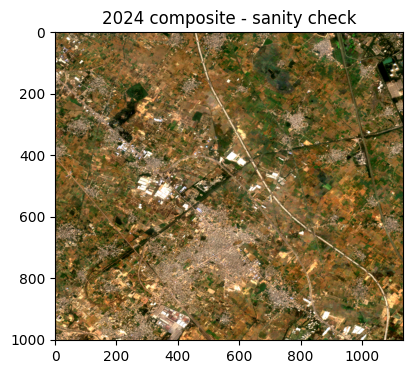

In [64]:
import matplotlib.pyplot as plt
import rasterio

with rasterio.open(path_2024) as src:
    img = src.read([1, 2, 3])
    img = img.transpose(1, 2, 0)
plt.figure(figsize=(12, 4))
plt.imshow(img)
plt.title('2024 composite - sanity check')
plt.show()

In [66]:
import rasterio
from rasterio.windows import Window
import numpy as np

def extract_patches(tif_path,patch_size=64):
  patches=[]
  coords=[]
  with rasterio.open(tif_path) as src:
    width,height=src.width,src.height
    for row,y in enumerate(range(0,height-patch_size+1,patch_size)):
      for col,x in enumerate(range(0,width-patch_size+1,patch_size)):
        window=Window(x,y,patch_size,patch_size)
        patch=src.read([1,2,3],window=window)
        patch=patch.transpose(1,2,0)
        patches.append(patch)
        coords.append((row,col))
  return patches,coords
patches_2017, coords_2017 = extract_patches('/content/drive/MyDrive/eurosat-project/noida2017 (2).tif')
patches_2024, coords_2024 = extract_patches('/content/drive/MyDrive/eurosat-project/noida2024 (3).tif')

print(len(patches_2017), len(patches_2024))
print('Grid shape (rows, cols):', max(c[0] for c in coords_2017)+1, max(c[1] for c in coords_2017)+1)

255 255
Grid shape (rows, cols): 15 17


In [67]:
import torch
from torchvision import transforms
from PIL import Image

eval_transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


def classify_patches(patches,model,batch_size=32):
  model.eval()
  prediction=[]
  tensors=[eval_transform(Image.fromarray(p)) for p in patches]
  with torch.no_grad():
    for i in range(0,len(tensors),batch_size):
      batch=torch.stack(tensors[i:i+batch_size]).to('cpu')
      outputs=model(batch)
      _,predicted=torch.max(outputs,1)
      prediction.extend(predicted.cpu().numpy())
  return prediction
preds_2017 = classify_patches(patches_2017, model)
preds_2024 = classify_patches(patches_2024, model)

print(len(preds_2017), len(preds_2024))

255 255


In [69]:
import numpy as np
from collections import Counter

print('2017 class distribution:')
print(Counter([class_names[p] for p in preds_2017]))

print('2024 class distribution:')
print(Counter([class_names[p] for p in preds_2024]))

2017 class distribution:
Counter({'AnnualCrop': 132, 'Forest': 45, 'Industrial': 36, 'SeaLake': 26, 'PermanentCrop': 9, 'Highway': 6, 'River': 1})
2024 class distribution:
Counter({'AnnualCrop': 91, 'Industrial': 67, 'Forest': 26, 'Highway': 26, 'PermanentCrop': 21, 'SeaLake': 20, 'Residential': 4})


In [74]:
import pandas as pd
transition_counts = pd.DataFrame(0, index=class_names, columns=class_names)

for pred_2017, pred_2024 in zip(preds_2017, preds_2024):
    from_class = class_names[pred_2017]
    to_class = class_names[pred_2024]
    transition_counts.loc[from_class, to_class] += 1

print(transition_counts)

                      AnnualCrop  Forest  HerbaceousVegetation  Highway  \
AnnualCrop                    62       9                     0       16   
Forest                         8       9                     0        1   
HerbaceousVegetation           0       0                     0        0   
Highway                        0       0                     0        5   
Industrial                     9       4                     0        2   
Pasture                        0       0                     0        0   
PermanentCrop                  1       1                     0        1   
Residential                    0       0                     0        0   
River                          0       0                     0        1   
SeaLake                       11       3                     0        0   

                      Industrial  Pasture  PermanentCrop  Residential  River  \
AnnualCrop                    25        0             13            0      0   
Forest        

In [76]:
forest_row=transition_counts.loc['Forest']
forest_total_2017=forest_row.sum()
forest_stayed=forest_row['Forest']
forest_lost=forest_total_2017-forest_stayed

print(f'forest patches in 2017:{forest_total_2017}')
print(f'forest patches that changed by 2024:{forest_lost}')
print('breakdown of what forest became:')
print(forest_row.drop('Forest').sort_values(ascending=False))

forest patches in 2017:45
forest patches that changed by 2024:36
breakdown of what forest became:
Industrial              16
AnnualCrop               8
Residential              4
SeaLake                  4
PermanentCrop            3
Highway                  1
HerbaceousVegetation     0
Pasture                  0
River                    0
Name: Forest, dtype: int64


In [77]:
urban_classes=['Industrial','Residential','Highway']
became_urban=transition_counts[urban_classes].sum(axis=1)
became_urban=became_urban[became_urban>0].sort_values(ascending=False)

print('What became urban infrastructure by 2024, broken down by 2017 origin:')
print(became_urban)

What became urban infrastructure by 2024, broken down by 2017 origin:
AnnualCrop       41
Forest           21
Industrial       21
Highway           5
SeaLake           5
PermanentCrop     3
River             1
dtype: int64


In [78]:
natural_classes = [c for c in class_names if c not in urban_classes]
new_urbanization = transition_counts.loc[natural_classes, urban_classes].sum(axis=1)
new_urbanization = new_urbanization[new_urbanization > 0].sort_values(ascending=False)
print(new_urbanization)

AnnualCrop       41
Forest           21
SeaLake           5
PermanentCrop     3
River             1
dtype: int64


In [83]:
gfc = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')

loss_band = gfc.select('loss')
lossyear_band = gfc.select('lossyear')

loss_2017_onward = lossyear_band.gte(17)
loss_area = loss_2017_onward.multiply(ee.Image.pixelArea())

stats = loss_area.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=30,
    maxPixels=1e9
).getInfo()

print('GFW-reported forest loss area (sq meters) since 2017:', stats)

GFW-reported forest loss area (sq meters) since 2017: {'lossyear': 14171.206237792969}


In [84]:
treecover2000 = gfc.select('treecover2000')

tc_stats = treecover2000.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=30,
    maxPixels=1e9
).getInfo()

print('Mean tree cover % (year 2000 baseline) in ROI:', tc_stats)

Mean tree cover % (year 2000 baseline) in ROI: {'treecover2000': 0.12528663387747094}


45 patches classified as Forest in 2017


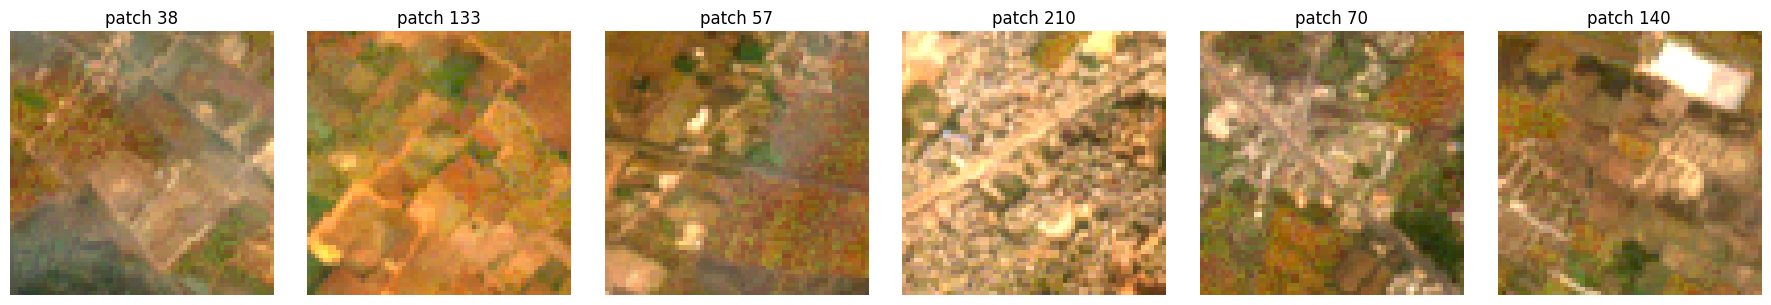

In [85]:
import numpy as np
import matplotlib.pyplot as plt

forest_idx_2017 = [i for i, p in enumerate(preds_2017) if class_names[p] == 'Forest']
print(f'{len(forest_idx_2017)} patches classified as Forest in 2017')

sample = np.random.choice(forest_idx_2017, min(6, len(forest_idx_2017)), replace=False)

fig, axes = plt.subplots(1, len(sample), figsize=(18, 3))
for i, idx in enumerate(sample):
    axes[i].imshow(patches_2017[idx])
    axes[i].set_title(f'patch {idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()